# Generic Pipeline — Validated on a Real, Independent Dataset


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data.dataset_config import DATASET_REGISTRY, UPI_CONFIG, CREDITCARD_CONFIG
from data.generic_pipeline import run_pipeline
from sklearn.ensemble import RandomForestClassifier
from models.evaluate import evaluate_model, print_report, print_summary, plot_confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. The Config System


In [2]:
print("=== UPI dataset config ===")
print(UPI_CONFIG)
print()
print("=== Credit card dataset config ===")
print(CREDITCARD_CONFIG)

=== UPI dataset config ===
DatasetConfig(name='UPI Transactions (synthetic)', path='data/raw/upi_transactions.csv', target_column='transaction_status', fraud_labels={'Fraud'}, id_columns=['transaction_id', 'sender_account_name', 'receiver_account_name'], timestamp_column='timestamp', seconds_column=None, amount_column='transaction_amount', categorical_columns=['sender_bank', 'receiver_bank', 'transaction_location', 'device_type'], flag_columns=['is_new_beneficiary', 'location_mismatch_flag', 'device_change_flag'], numeric_columns=[], velocity_column='transactions_last_24h')

=== Credit card dataset config ===
DatasetConfig(name='ULB Credit Card Fraud Detection (real data)', path='data/external/creditcard.csv', target_column='Class', fraud_labels={1}, id_columns=[], timestamp_column=None, seconds_column='Time', amount_column='Amount', categorical_columns=[], flag_columns=[], numeric_columns=['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 

## 2. Real Dataset Overview


In [3]:
raw = pd.read_csv("../data/external/creditcard.csv")
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))
print("\nFraud count in this sample:", raw["Class"].sum())
raw.head()

Shape: (50492, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Fraud count in this sample: 492


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,66706.0,1.199490,0.197301,0.616923,0.554820,-0.526523,-0.785182,-0.036202,-0.070460,-0.224568,...,-0.191542,-0.597586,0.148051,0.529668,0.158453,0.064369,-0.033132,0.011166,3.59,0
1,118737.0,2.054939,-0.005134,-1.050691,0.401563,-0.047484,-1.112092,0.218426,-0.350042,0.430742,...,-0.275390,-0.616070,0.338719,0.006520,-0.288834,0.198696,-0.062744,-0.059034,1.29,0
2,67555.0,-0.943726,-0.366261,2.292128,-1.909816,-0.305247,1.903637,-0.998268,0.757791,0.170689,...,0.109482,0.651761,-0.502554,-1.659885,0.669679,-0.000532,0.228359,0.088451,2.00,0
3,6428.0,-0.960946,0.864361,1.286077,0.131434,0.630708,-0.746227,0.567456,-0.281288,0.965197,...,-0.375636,-0.589018,0.275299,-0.161066,-0.491036,-0.020583,0.150700,0.179427,5.36,0
4,159884.0,1.688499,0.142083,-2.975027,0.857739,0.752403,-1.699499,0.883376,-0.527584,-0.050348,...,0.021742,-0.179006,-0.069067,0.967166,0.029453,0.613583,-0.095408,0.044466,195.00,0


## 3. Run the Same Pipeline Against Both Datasets

In [4]:
results = {}

for key in ["upi", "creditcard"]:
    config = DATASET_REGISTRY[key]
    print(f"--- Running pipeline on: {config.name} ---")
    X_train_bal, X_test_proc, y_train_bal, y_test, feature_names, artifacts = run_pipeline(config, save=True)
    print(f"Train (balanced): {X_train_bal.shape}, fraud rate: {y_train_bal.mean():.3f}")
    print(f"Test (untouched):  {X_test_proc.shape}, fraud rate: {y_test.mean():.4f}")
    print(f"Feature count: {len(feature_names)}\n")
    results[key] = (X_train_bal, X_test_proc, y_train_bal, y_test, feature_names, artifacts)

--- Running pipeline on: UPI Transactions (synthetic) ---


Train (balanced): (220930, 59), fraud rate: 0.500
Test (untouched):  (30000, 59), fraud rate: 0.0795
Feature count: 59

--- Running pipeline on: ULB Credit Card Fraud Detection (real data) ---


Train (balanced): (79998, 35), fraud rate: 0.500
Test (untouched):  (10099, 35), fraud rate: 0.0097
Feature count: 35



## 4. Train Random Forest on the Real Credit Card Data

In [5]:
X_train_bal, X_test_proc, y_train_bal, y_test, feature_names, artifacts = results["creditcard"]

rf_cc = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_cc.fit(X_train_bal, y_train_bal)

cc_metrics = evaluate_model(rf_cc, X_test_proc, y_test, model_name="RandomForest_CreditCard", save=True)
print_summary(cc_metrics)

Model: RandomForest_CreditCard
  Accuracy:  0.9984
  Precision: 0.9457
  Recall:    0.8878
  F1 Score:  0.9158
  ROC-AUC:   0.9814


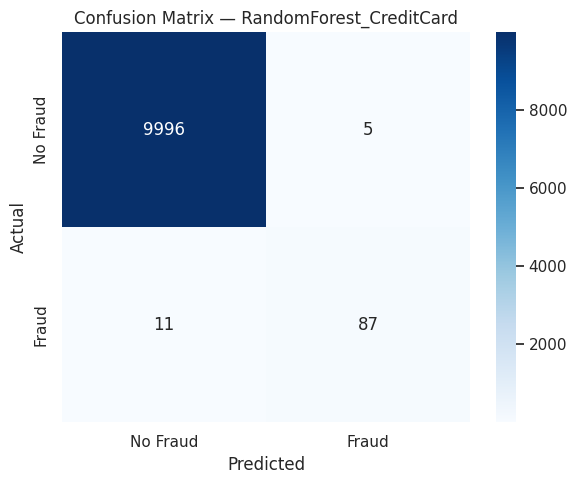

In [6]:
fig, ax = plot_confusion_matrix(cc_metrics, save_path="../reports/figures/31_creditcard_confusion_matrix.png")
plt.show()

## 5. Feature Importance on Real Data


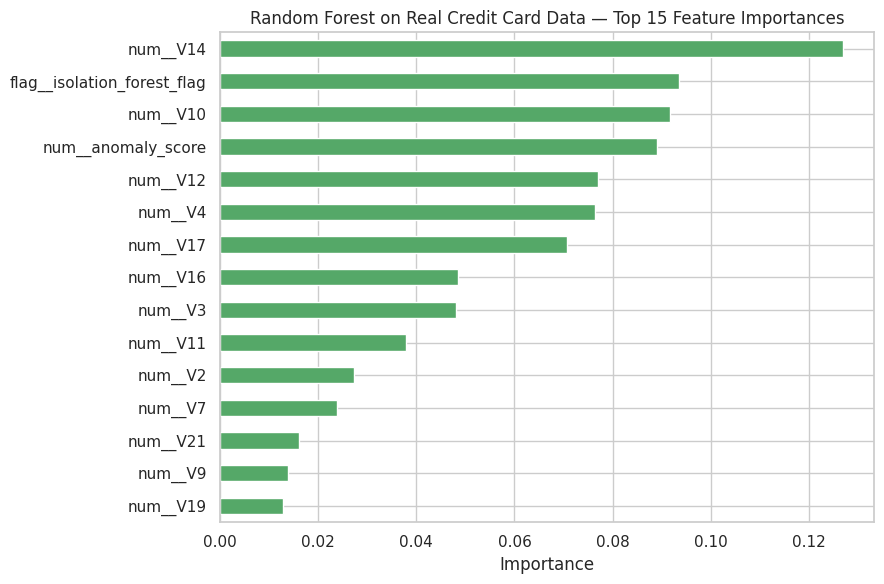

In [7]:
importances = pd.Series(rf_cc.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top_features.sort_values().plot(kind="barh", color="#55A868", ax=ax)
ax.set_title("Random Forest on Real Credit Card Data — Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../reports/figures/32_creditcard_feature_importance.png", dpi=150)
plt.show()

## 6. Side-by-Side: Synthetic UPI vs. Real Credit Card Data

In [8]:
import json
with open("../reports/metrics/RandomForest_metrics.json") as f:
    upi_rf_metrics = json.load(f)

comparison = pd.DataFrame({
    "UPI (synthetic)": {
        "Accuracy": upi_rf_metrics["accuracy"], "Precision": upi_rf_metrics["precision"],
        "Recall": upi_rf_metrics["recall"], "F1": upi_rf_metrics["f1_score"],
        "ROC-AUC": upi_rf_metrics.get("roc_auc"),
    },
    "Credit Card (real)": {
        "Accuracy": cc_metrics["accuracy"], "Precision": cc_metrics["precision"],
        "Recall": cc_metrics["recall"], "F1": cc_metrics["f1_score"],
        "ROC-AUC": cc_metrics.get("roc_auc"),
    },
}).T.round(4)
comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
UPI (synthetic),0.9939,0.9508,0.9732,0.9619,0.9990
Credit Card (real),0.9984,0.9457,0.8878,0.9158,0.9814


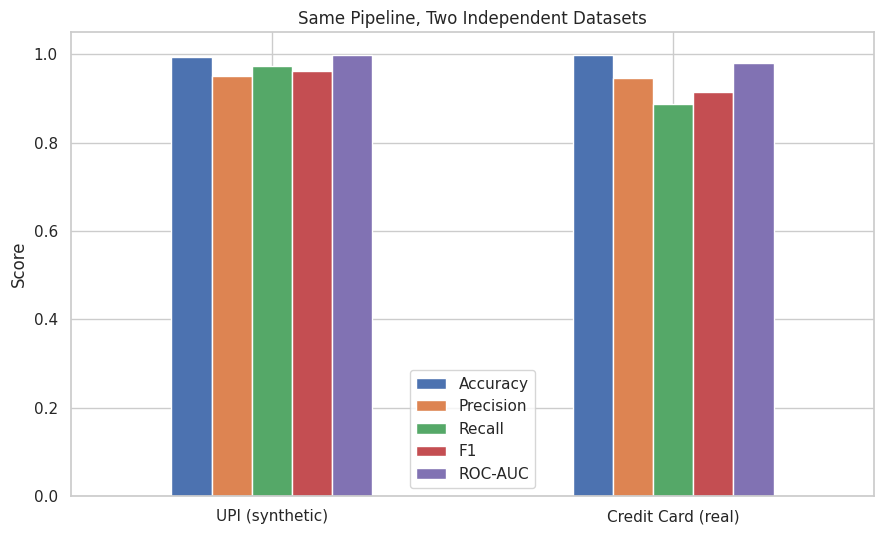

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
comparison.plot(kind="bar", ax=ax)
ax.set_title("Same Pipeline, Two Independent Datasets")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/33_generic_pipeline_comparison.png", dpi=150)
plt.show()